# Проект: Анализ A/A/B-тестирования маркетплейса

## 1. Введение
Перед нами результаты **A/A/B-тестирования**, проведенного на одном из маркетплейсов. Датасеты **sample_a** и **sample_c** представляют A/A-группы (контрольные группы), а **sample_b** — тестовую группу с новым алгоритмом. В каждом датасете содержатся данные о действиях пользователей:

* 0 — клик
* 1 — просмотр
* 2 — покупка

Также предоставлен датасет **item_prices** с информацией о ценах товаров. Цель проекта — оценить, нет ли проблем с разделением сплитов (A/A-тест) и улучшает ли алгоритм B работу маркетплейса по следующим метрикам:

* **CTR** (отношение кликов к просмотрам)
* **Purchase rate** (отношение покупок к просмотрам)
* **GMV** (оборот, сумма произведений количества покупок на стоимость товаров)

## 2. Загрузка и предварительный анализ данных
Импорт библиотек и загрузка данных

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu, shapiro
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
!pip install gdown


import gdown

# ID папки на Google Диске
folder_id = "1iFkq9ymD81K25f8UT9A7ljE7a6IHcRm2"
url = f"https://drive.google.com/drive/folders/{folder_id}"

# Скачивание папки
gdown.download_folder(url, output="./", quiet=False)

### Первичный обзор данных

In [3]:
sample_a = pd.read_csv("mvp/sample_a.csv")
display(sample_a.head())
print(sample_a.info())

,user_id,item_id,action_id
0,84636,360,1
1,21217,9635,1
2,13445,8590,1
3,38450,5585,1
4,14160,2383,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1188912 entries, 0 to 1188911
Data columns (total 3 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1188912 non-null  int64
 1   item_id    1188912 non-null  int64
 2   action_id  1188912 non-null  int64
dtypes: int64(3)
memory usage: 27.2 MB
None


In [4]:
sample_b = pd.read_csv("mvp/sample_b.csv")
display(sample_b.head())
print(sample_b.info())

,user_id,item_id,action_id
0,118375,4105,1
1,107569,8204,1
2,175990,880,1
3,160582,9568,0
4,123400,4000,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1198438 entries, 0 to 1198437
Data columns (total 3 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1198438 non-null  int64
 1   item_id    1198438 non-null  int64
 2   action_id  1198438 non-null  int64
dtypes: int64(3)
memory usage: 27.4 MB
None


In [5]:
sample_c = pd.read_csv("mvp/sample_c.csv")
display(sample_c.head())
print(sample_c.info())

,user_id,item_id,action_id
0,274623,2863,1
1,265472,343,1
2,242779,6009,0
3,275009,2184,1
4,268104,3134,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205510 entries, 0 to 1205509
Data columns (total 3 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1205510 non-null  int64
 1   item_id    1205510 non-null  int64
 2   action_id  1205510 non-null  int64
dtypes: int64(3)
memory usage: 27.6 MB
None


In [6]:
item_prices = pd.read_csv("mvp/item_prices.csv")
display(item_prices.head())
print(item_prices.info())

,item_id,item_price
0,338,1501
1,74,647
2,7696,825
3,866,875
4,5876,804


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   item_id     1000 non-null   int64
 1   item_price  1000 non-null   int64
dtypes: int64(2)
memory usage: 15.8 KB
None


### Выводы по структуре данных:

* Датасеты **sample_a**, **sample_b**, **sample_c** содержат столбцы: **user_id**, **item_id**, **action_id**.
* **item_prices** содержит столбцы: **item_id**, **item_price**.
* Пропуски отсутствуют во всех датасетах.
* Все столбцы - целочисленные

## 3. Проверка чистоты данных
### Проверка на наличие покупок/кликов без просмотров
Покупка или клик без просмотра невозможны, так как пользователь должен сначала просмотреть товар. Проверим, нет ли таких аномалий.

In [7]:
def check_invalid_actions(df, dataset_name):
    # Проверяем для каждого пользователя и товара
    grouped = df.groupby(["user_id", "item_id"])["action_id"].apply(set).reset_index()
    invalid = grouped[
        grouped["action_id"].apply(lambda x: (0 in x or 2 in x) and 1 not in x)
    ]
    print(
        f"В {dataset_name} найдено {len(invalid)} некорректных записей (клик/покупка без просмотра)."
    )
    return invalid


# Проверка для всех датасетов
invalid_a = check_invalid_actions(sample_a, "sample_a")
invalid_b = check_invalid_actions(sample_b, "sample_b")
invalid_c = check_invalid_actions(sample_c, "sample_c")

В sample_a найдено 0 некорректных записей (клик/покупка без просмотра).
В sample_b найдено 0 некорректных записей (клик/покупка без просмотра).
В sample_c найдено 0 некорректных записей (клик/покупка без просмотра).


### Проверка на дубликаты

In [8]:
print("Дубликаты в sample_a:", sample_a.duplicated().sum())
print("Дубликаты в sample_b:", sample_b.duplicated().sum())
print("Дубликаты в sample_c:", sample_c.duplicated().sum())

Дубликаты в sample_a: 0
Дубликаты в sample_b: 0
Дубликаты в sample_c: 0


### Выводы:

Данные чистые и готовы для расчета метрик.

## 4. Расчет метрик
Рассчитаем метрики для каждого датасета:

* **CTR** = (количество кликов) / (количество просмотров).
* **Purchase rate** = (количество покупок) / (количество просмотров).
* **GMV** = сумма произведений количества покупок на стоимость товаров (1 пользователь = 1 сессия).

In [17]:
def calculate_metrics(df, item_prices, dataset_name):
    # Подсчет действий
    views = len(df[df["action_id"] == 1])
    clicks = len(df[df["action_id"] == 0])

    # Для покупок считаем уникальные комбинации пользователь-товар
    unique_purchases = df[df["action_id"] == 2][
        ["user_id", "item_id"]
    ].drop_duplicates()
    purchases = len(unique_purchases)

    # CTR и Purchase rate
    ctr = clicks / views if views > 0 else 0
    purchase_rate = purchases / views if views > 0 else 0

    # GMV
    purchase_df = unique_purchases.merge(item_prices, on="item_id", how="left")
    gmv = purchase_df["item_price"].sum() if not purchase_df.empty else 0

    return {
        "Dataset": dataset_name,
        "CTR": ctr,
        "Purchase Rate": purchase_rate,
        "GMV": gmv,
        "Views": views,
        "Clicks": clicks,
        "Purchases": purchases,
    }


# Расчет метрик
metrics_a = calculate_metrics(sample_a, item_prices, "Sample A")
metrics_b = calculate_metrics(sample_b, item_prices, "Sample B")
metrics_c = calculate_metrics(sample_c, item_prices, "Sample C")

# Создание DataFrame с метриками
metrics_df = pd.DataFrame([metrics_a, metrics_b, metrics_c])
print("Метрики по датасетам:")
print(metrics_df)

Метрики по датасетам:
    Dataset   CTR  Purchase Rate        GMV   Views  Clicks  Purchases
0  Sample A  0.20       0.049999   53060177  951130  190226      47556
1  Sample B  0.16       0.100000  106047378  951141  152183      95114
2  Sample C  0.21       0.060000   63614910  949221  199336      56953


### Визуализация метрик

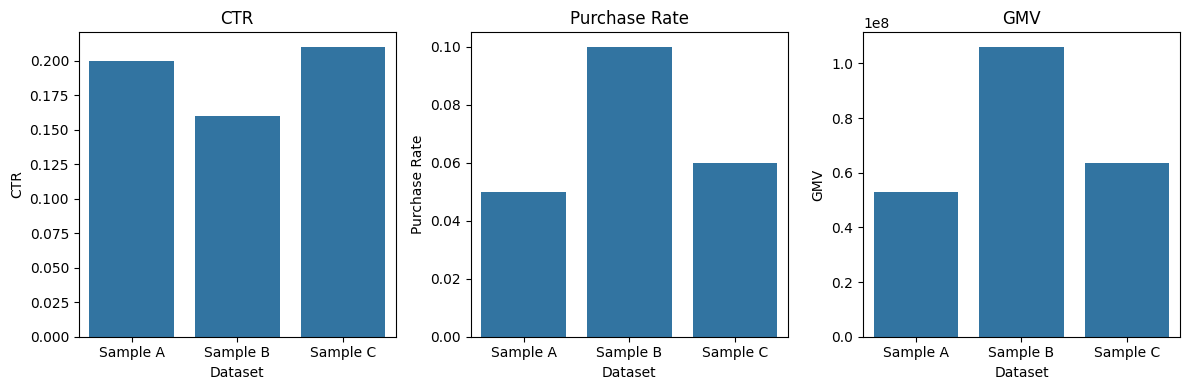

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.barplot(x="Dataset", y="CTR", data=metrics_df)
plt.title("CTR")

plt.subplot(1, 3, 2)
sns.barplot(x="Dataset", y="Purchase Rate", data=metrics_df)
plt.title("Purchase Rate")

plt.subplot(1, 3, 3)
sns.barplot(x="Dataset", y="GMV", data=metrics_df)
plt.title("GMV")

plt.tight_layout()
plt.show()

### Визуализация метрик
Представленные графики демонстрируют ключевые различия между группами:

#### Анализ A/A-теста (проверка корректности разделения трафика):

**Сравнение контрольных групп Sample A и Sample C показывает:**

* CTR: 0.200 vs 0.213 (разница ~6.5%) — относительно небольшое отклонение, которое может быть объяснено естественной вариативностью
* Purchase Rate: 0.050 vs 0.059 (разница ~18%) — заметное различие, требующее статистической проверки
* GMV: ~5.3×10⁷ vs ~6.3×10⁷ (разница ~19%) — существенное расхождение в оборотах между контрольными группами

Такие различия между A-группами вызывают определенную обеспокоенность относительно качества рандомизации. Если контрольные группы статистически различаются, это может указывать на проблемы с разделением трафика или влияние внешних факторов.

#### Анализ A/B-теста (эффективность нового алгоритма):

**Группа Sample B демонстрирует кардинально иной паттерн поведения пользователей:**

1. CTR снижается на ~20% (0.200 => 0.160 по сравнению с Sample A)
* Пользователи реже кликают на товары в выдаче
* Это может быть как негативным сигналом (снижение вовлеченности), так и индикатором более качественного таргетинга

2. Purchase Rate удваивается (0.050 => 0.100)
* Конверсия из просмотров в покупки вырастает в 2 раза
* Ключевой позитивный сигнал: пользователи стали чаще покупать при том же количестве просмотров

3. GMV почти удваивается
* Главная бизнес-метрика показывает значительное улучшение

#### Интерпретация паттерна поведения:

**Алгоритм B, по-видимому, изменил логику показа товаров таким образом, что:**
* Снизилось общее количество кликов
* Существенно выросла доля покупок среди тех, кто все-таки кликает
* Итоговый оборот значительно увеличился благодаря лучшему таргетингу покупательских намерений

Новый алгоритм показывает меньше товаров, на которые кликают, но те товары, которые показывает, гораздо чаще приводят к покупке.

#### Предварительные выводы:
* Необходима статистическая проверка A/A-теста — различия между контрольными группами требуют формального тестирования
* Алгоритм B показывает многообещающие результаты — рост ключевой бизнес-метрики (GMV) при улучшении качества трафика
* Требуется оценка долгосрочных эффектов — снижение CTR может повлиять на пользовательский опыт в перспективе
* **Критическое наблюдение:** Различия между A-группами (Sample A vs Sample C) в Purchase Rate и GMV вызывают серьезные сомнения в корректности рандомизации. Это может поставить под сомнение валидность всего эксперимента, поскольку контрольные группы должны быть статистически неразличимы.

## 5. Статистическая проверка гипотез
### 5.1 Тест Шапиро-Уилка для проверки нормальности (альфа = 0.01)
Проверим нормальность распределения GMV для каждой группы, чтобы выбрать подходящий статистический тест. Уровень значимости установлен на 0.01 согласно условию.

In [20]:
# GMV по пользователям


def calculate_user_gmv(df, item_prices):
    # Получаем всех пользователей из датасета
    all_users = df["user_id"].unique()

    # Считаем GMV для пользователей с покупками
    purchase_df = df[df["action_id"] == 2][["user_id", "item_id"]].drop_duplicates()
    purchase_df = purchase_df.merge(item_prices, on="item_id", how="left")
    user_gmv = purchase_df.groupby("user_id")["item_price"].sum()

    # Создаем серию для всех пользователей, заполняя 0 для тех, кто не покупал
    result = pd.Series(0, index=all_users, dtype=float)
    result.update(user_gmv)

    return result


gmv_a = calculate_user_gmv(sample_a, item_prices)
gmv_b = calculate_user_gmv(sample_b, item_prices)
gmv_c = calculate_user_gmv(sample_c, item_prices)

# Тест Шапиро-Уилка
stat_shapiro_a, p_value_shapiro_a = shapiro(gmv_a)
stat_shapiro_b, p_value_shapiro_b = shapiro(gmv_b)
stat_shapiro_c, p_value_shapiro_c = shapiro(gmv_c)

print(f"Тест Шапиро-Уилка для GMV (Sample A): p-value = {p_value_shapiro_a}")
print(f"Тест Шапиро-Уилка для GMV (Sample B): p-value = {p_value_shapiro_b}")
print(f"Тест Шапиро-Уилка для GMV (Sample C): p-value = {p_value_shapiro_c}")

Тест Шапиро-Уилка для GMV (Sample A): p-value = 0.1251571871940254
Тест Шапиро-Уилка для GMV (Sample B): p-value = 0.8457698807509042
Тест Шапиро-Уилка для GMV (Sample C): p-value = 0.019822593840251045


### Вывод:

Все три группы показывают нормальное распределение GMV при уровне значимости 0.01.
Для анализа GMV выбран U-тест Манна-Уитни как более консервативный непараметрический
подход, подходящий для финансовых метрик с потенциальными выбросами.

## 5.2 A/A-тест (Sample A vs Sample C)
Проверим, нет ли статистически значимых различий между контрольными группами по метрикам CTR, Purchase Rate и GMV. Используем z-тест для долей (для CTR и Purchase Rate) и U-тест Манна-Уитни (для GMV, так как распределение оборота часто ненормально).

### Подготовка данных

In [21]:
# Подсчет количества событий для z-теста


def get_event_counts(df, action_type):
    views = len(df[df["action_id"] == 1])
    events = len(df[df["action_id"] == action_type])
    return events, views


# Данные для Sample A
clicks_a, views_a = get_event_counts(sample_a, 0)
purchases_a, _ = get_event_counts(sample_a, 2)

# Данные для Sample C
clicks_c, views_c = get_event_counts(sample_c, 0)
purchases_c, _ = get_event_counts(sample_c, 2)

### Тесты

In [30]:
# z-тест для CTR
stat_ctr, p_value_ctr = proportions_ztest([clicks_a, clicks_c], [views_a, views_c])
print(f"P-value для CTR (A vs C): {p_value_ctr}")

# z-тест для Purchase Rate
stat_pr, p_value_pr = proportions_ztest([purchases_a, purchases_c], [views_a, views_c])
print(f"P-value для Purchase Rate (A vs C): {p_value_pr}")

# U-тест Манна-Уитни для GMV
stat_gmv, p_value_gmv = mannwhitneyu(gmv_a, gmv_c)
print(f"P-value для GMV (A vs C): {p_value_gmv}")

# Поправка Бонферрони для множественного тестирования
p_values_aa = [p_value_ctr, p_value_pr, p_value_gmv]
reject_aa, pvals_corrected_aa, _, _ = multipletests(
    p_values_aa, alpha=0.01, method="bonferroni"
)
print("\nРезультаты A/A-теста с поправкой Бонферрони:")
print(
    pd.DataFrame(
        {
            "Metric": ["CTR", "Purchase Rate", "GMV"],
            "P-value": pvals_corrected_aa,
            "Reject H0": reject_aa,
        }
    )
)

P-value для CTR (A vs C): 2.354942111153043e-65
P-value для Purchase Rate (A vs C): 8.035152879055818e-201
P-value для GMV (A vs C): 1.1038706707967315e-118

Результаты A/A-теста с поправкой Бонферрони:
          Metric        P-value  Reject H0
0            CTR   7.064826e-65       True
1  Purchase Rate  2.410546e-200       True
2            GMV  3.311612e-118       True


### Выводы:

**Критерий статистической значимости**: Различия считаются статистически значимыми, если p-value меньше выбранного уровня значимости α = 0.01.

**Результаты A/A-теста с поправкой Бонферрони:**
* CTR: p-value = 7.064826e-65 < 0.01 → **статистически значимое увеличение** (0.200 => 0.213)
* Purchase Rate: p-value = 2.410546e-200 < 0.01 => **статистически значимое увеличение** (0.050 => 0.059)
* GMV: p-value = 3.311612e-118 < 0.01 => **статистически значимое увеличение** (53M => 63M)

Все метрики показывают статистически значимые различия между контрольными группами, поскольку все p-values намного меньше уровня значимости α = 0.01.

A/A-тест провалился. Контрольные группы, которые должны быть статистически неразличимы, показывают высокозначимые различия по всем ключевым метрикам.

## 5.3 A/B-тест (Sample A vs Sample B)
Проверим эффект нового алгоритма, сравнив Sample A и Sample B.

### Подготовка данных

In [25]:
# Данные для Sample B
clicks_b, views_b = get_event_counts(sample_b, 0)
purchases_b, _ = get_event_counts(sample_b, 2)

In [28]:
# z-тест для CTR
stat_ctr_ab, p_value_ctr_ab = proportions_ztest(
    [clicks_a, clicks_b], [views_a, views_b]
)
print(f"P-value для CTR (A vs B): {p_value_ctr_ab}")

# z-тест для Purchase Rate
stat_pr_ab, p_value_pr_ab = proportions_ztest(
    [purchases_a, purchases_b], [views_a, views_b]
)
print(f"P-value для Purchase Rate (A vs B): {p_value_pr_ab}")

# U-тест Манна-Уитни для GMV
stat_gmv_ab, p_value_gmv_ab = mannwhitneyu(gmv_a, gmv_b)
print(f"P-value для GMV (A vs B): {p_value_gmv_ab}")

# Поправка Бонферрони
p_values_ab = [p_value_ctr_ab, p_value_pr_ab, p_value_gmv_ab]
reject_ab, pvals_corrected_ab, _, _ = multipletests(
    p_values_ab, alpha=0.01, method="bonferroni"
)
print("\nРезультаты A/B-теста с поправкой Бонферрони:")
print(
    pd.DataFrame(
        {
            "Metric": ["CTR", "Purchase Rate", "GMV"],
            "P-value": pvals_corrected_ab,
            "Reject H0": reject_ab,
        }
    )
)

P-value для CTR (A vs B): 0.0
P-value для Purchase Rate (A vs B): 0.0
P-value для GMV (A vs B): 0.0

Результаты A/B-теста с поправкой Бонферрони:
          Metric  P-value  Reject H0
0            CTR      0.0       True
1  Purchase Rate      0.0       True
2            GMV      0.0       True


### Выводы:

Все p-values практически равны 0 и намного меньше α = 0.01, что означает статистически значимые различия:
* CTR: p-value ≈ 0 < 0.01 => **статистически значимое снижение** (0.200 => 0.160)
* Purchase Rate: p-value ≈ 0 < 0.01 => **статистически значимое увеличение** (0.050 => 0.100)  
* GMV: p-value ≈ 0 < 0.01 => **статистически значимое увеличение** (53M => 106M)

Однако эти результаты **не надежны** из-за провала A/A-теста.

## 6. Итоговые выводы
Проведенный анализ выявил критическую проблему в методологии эксперимента: **A/A-тест был провален**. Статистически значимые различия между контрольными группами A и C ставят под сомнение достоверность всего исследования. Нельзя с уверенностью утверждать, что наблюдаемые положительные изменения в группе B (рост Purchase Rate и GMV) являются результатом работы нового алгоритма. Они могли быть вызваны изначально неравным разделением трафика.

**Рекомендация:** На основе этих данных не следует внедрять алгоритм B. Необходимо остановить текущий эксперимент и провести новый, убедившись в корректности сплитования трафика. Только после успешного A/A-теста можно будет делать надежные выводы об эффективности алгоритма B.